# Clustering de riesgo ambiental

Este notebook aplica K-Means para identificar perfiles de riesgo ambiental a partir de contaminantes, condiciones meteorológicas, vulnerabilidad respiratoria y contexto industrial.

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

from src.preprocessing import (
    cargar_dataset,
    limpiar_dataset,
)


def encontrar_raiz_proyecto() -> Path:
    actual = Path.cwd().resolve()

    for candidato in [actual, *actual.parents]:
        if (
            (candidato / "src").is_dir()
            and (candidato / "notebooks").is_dir()
        ):
            return candidato

    raise FileNotFoundError(
        "No fue posible encontrar la raíz del proyecto."
    )


PROJECT_ROOT = encontrar_raiz_proyecto()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from src.preprocessing import (
    cargar_dataset_desde_api,
    limpiar_dataset,
)

from src.clustering import (
    agregar_clusters,
    asignar_etiquetas_riesgo,
    entrenar_kmeans,
    escalar_variables,
    evaluar_numero_clusters,
    obtener_centroides,
    resumir_clusters,
)

from src.visualizations import graficar_clusters

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print("Importaciones correctas")

Raíz del proyecto: C:\Users\yvl\Documents\GitHub\air-quality-monitoring-platform
Importaciones correctas


## Carga del dataset

El notebook utiliza primero el archivo procesado local. Si el archivo no está disponible, descarga los datos desde la API.

In [2]:
ruta_dataset = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "dataset_modelado.csv"
)

if ruta_dataset.exists():
    df_original = pd.read_csv(ruta_dataset)
    fuente_datos = ruta_dataset
else:
    df_original = cargar_dataset_desde_api()
    fuente_datos = "API"

df = limpiar_dataset(df_original)

print(f"Fuente de datos: {fuente_datos}")
print(f"Filas disponibles: {len(df)}")
print(f"Columnas disponibles: {len(df.columns)}")

df.head()

Fuente de datos: C:\Users\yvl\Documents\GitHub\air-quality-monitoring-platform\data\processed\dataset_modelado.csv
Filas disponibles: 26597
Columnas disponibles: 22


,fecha_hora,comuna,region,codigo_estacion,tipo_sensor,mp25,mp10,so2,no2,velocidad_viento,...,humedad,indice_vulnerabilidad_respiratoria,emision_maxima_permitida,categoria_ica,fecha,anio,mes,dia,hora,dia_semana
0,2026-06-01,Concepción,Biobío,SEN-CON-OF-001,publico_oficial,56.0,133.00,38.0,51.0,1.05,...,89.0,69.5,390.0,Regular,2026-06-01,2026,6,1,0,Monday
1,2026-06-01,Coronel,Biobío,SEN-COR-ONG-001,sensor_comunitario_ong,69.0,155.75,54.0,63.0,1.05,...,89.0,76.2,650.0,Regular,2026-06-01,2026,6,1,0,Monday
2,2026-06-01,Hualpén,Biobío,SEN-HUA-OF-001,publico_oficial,62.0,143.50,48.0,57.0,1.05,...,89.0,68.4,500.0,Regular,2026-06-01,2026,6,1,0,Monday
3,2026-06-01,Los Ángeles,Biobío,SEN-LAN-OF-001,publico_oficial,74.0,144.50,26.0,37.0,1.05,...,89.0,74.3,260.0,Regular,2026-06-01,2026,6,1,0,Monday
4,2026-06-01,Curicó,Maule,SEN-CUR-ONG-001,sensor_comunitario_ong,55.0,106.25,18.0,29.0,1.05,...,89.0,60.0,95.0,Regular,2026-06-01,2026,6,1,0,Monday


## Selección de variables

MP10 no se incluye porque presenta una correlación de 0.98 con MP2.5. Entre temperatura, humedad y velocidad del viento se selecciona únicamente la velocidad del viento, debido a la alta correlación existente entre estas variables meteorológicas.

Las variables seleccionadas representan:

- contaminación por material particulado;
- contaminación por gases;
- capacidad de dispersión atmosférica;
- vulnerabilidad respiratoria;
- contexto de emisiones industriales.

In [3]:
variables_propuestas = [
    "mp25",
    "so2",
    "no2",
    "velocidad_viento",
    "indice_vulnerabilidad_respiratoria",
    "emision_maxima_permitida",
]

variables_clustering = [
    variable
    for variable in variables_propuestas
    if variable in df.columns
]

variables_faltantes = [
    variable
    for variable in variables_propuestas
    if variable not in df.columns
]

print("Variables utilizadas:")
for variable in variables_clustering:
    print(f"- {variable}")

if variables_faltantes:
    print("\nVariables no disponibles:")
    for variable in variables_faltantes:
        print(f"- {variable}")

Variables utilizadas:
- mp25
- so2
- no2
- velocidad_viento
- indice_vulnerabilidad_respiratoria
- emision_maxima_permitida


Celda de diagnostico

In [4]:
diagnostico_variables = pd.DataFrame(
    {
        "variable": variables_clustering,
        "tipo": [
            str(df[variable].dtype)
            for variable in variables_clustering
        ],
        "nulos": [
            int(df[variable].isna().sum())
            for variable in variables_clustering
        ],
        "porcentaje_nulos": [
            round(df[variable].isna().mean() * 100, 2)
            for variable in variables_clustering
        ],
        "valores_unicos": [
            int(df[variable].nunique(dropna=True))
            for variable in variables_clustering
        ],
    }
)

display(diagnostico_variables)

,variable,tipo,nulos,porcentaje_nulos,valores_unicos
0,mp25,float64,0,0.00,1187
1,so2,float64,0,0.00,71
2,no2,float64,0,0.00,59
3,velocidad_viento,float64,0,0.00,126
4,indice_vulnerabilidad_respiratoria,float64,0,0.00,27
5,emision_maxima_permitida,float64,2082,7.83,24


## Preparación y estandarización

Los valores nulos se imputan mediante la mediana de cada variable. Posteriormente, las variables se estandarizan con `StandardScaler`, evitando que las diferencias de escala dominen el resultado de K-Means.

In [5]:
(
    X_scaled,
    scaler,
    datos_modelo,
    columnas_utilizadas,
) = escalar_variables(
    df,
    columnas=variables_clustering,
)

print(f"Registros preparados: {X_scaled.shape[0]}")
print(f"Variables utilizadas: {X_scaled.shape[1]}")
print(f"Valores nulos restantes: {datos_modelo.isna().sum().sum()}")

display(datos_modelo.describe().transpose().round(2))

Registros preparados: 26597
Variables utilizadas: 6
Valores nulos restantes: 0


,count,mean,std,min,25%,50%,75%,max
mp25,26597.0,45.61,23.46,9.00,29.90,37.40,60.75,178.05
so2,26597.0,30.92,14.40,12.00,19.00,25.00,41.00,82.00
no2,26597.0,48.17,12.41,28.00,39.00,45.00,58.00,86.00
velocidad_viento,26597.0,3.16,1.61,0.35,1.86,2.69,4.55,6.37
indice_vulnerabilidad_respiratoria,26597.0,67.37,5.33,54.80,63.20,67.80,72.70,76.20
emision_maxima_permitida,26597.0,294.24,159.57,90.00,155.00,260.00,420.00,650.00


## Evaluación del número de clusters

Se comparan valores de K entre 2 y 6 utilizando:

- **Inercia:** menor valor indica grupos más compactos.
- **Silhouette:** mayor valor indica una mejor separación entre grupos.

Celda de evaluación

In [6]:
evaluacion = evaluar_numero_clusters(
    X_scaled,
    min_clusters=2,
    max_clusters=6,
    random_state=42,
)

display(
    evaluacion.round(
        {
            "inercia": 2,
            "silhouette": 4,
        }
    )
)

,n_clusters,inercia,silhouette
0,2,105920.98,0.3236
1,3,83614.17,0.2782
2,4,71222.54,0.2661
3,5,62958.93,0.2581
4,6,56107.22,0.2728


Gráfico de inercia

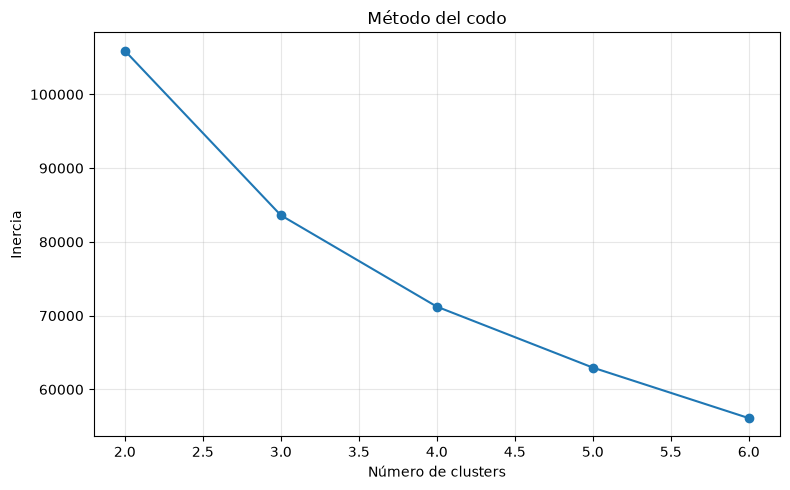

In [7]:
figura, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    evaluacion["n_clusters"],
    evaluacion["inercia"],
    marker="o",
)

ax.set_title("Método del codo")
ax.set_xlabel("Número de clusters")
ax.set_ylabel("Inercia")
ax.grid(alpha=0.3)

figura.tight_layout()
plt.show()

Gráfico de silhouette

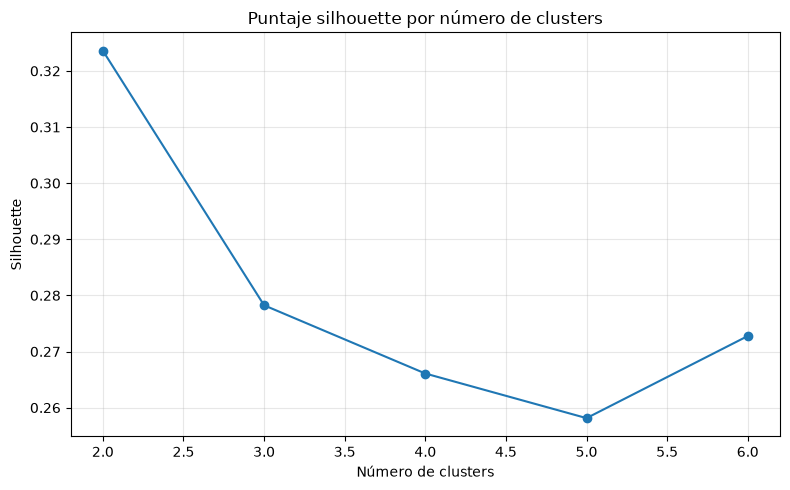

In [8]:
figura, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    evaluacion["n_clusters"],
    evaluacion["silhouette"],
    marker="o",
)

ax.set_title("Puntaje silhouette por número de clusters")
ax.set_xlabel("Número de clusters")
ax.set_ylabel("Silhouette")
ax.grid(alpha=0.3)

figura.tight_layout()
plt.show()